## Textbook code

In [6]:
# coding: utf-8
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [7]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01

In [8]:
def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784,
                                     hidden_size_list=[100, 100, 100, 100, 100],
                                     output_size=10,
                                     weight_init_std=weight_init_std,
                                     use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784,
                                  hidden_size_list=[100, 100, 100, 100, 100],
                                  output_size=10,
                                  weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - "
                  + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list




============== 1/16 ==============
epoch:0 | 0.097 - 0.12
epoch:1 | 0.097 - 0.121


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\./official_github\common\functions.py:56: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\./official_github\common\functions.py:34: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


epoch:2 | 0.097 - 0.13
epoch:3 | 0.097 - 0.133
epoch:4 | 0.097 - 0.146
epoch:5 | 0.097 - 0.161
epoch:6 | 0.097 - 0.183
epoch:7 | 0.097 - 0.191
epoch:8 | 0.097 - 0.207
epoch:9 | 0.097 - 0.225
epoch:10 | 0.097 - 0.243
epoch:11 | 0.097 - 0.251
epoch:12 | 0.097 - 0.274
epoch:13 | 0.097 - 0.29
epoch:14 | 0.097 - 0.306
epoch:15 | 0.097 - 0.328
epoch:16 | 0.097 - 0.346
epoch:17 | 0.097 - 0.364
epoch:18 | 0.097 - 0.374
epoch:19 | 0.097 - 0.398
============== 2/16 ==============
epoch:0 | 0.093 - 0.099


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\./official_github\common\multi_layer_net_extend.py:104: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\./official_github\common\multi_layer_net_extend.py:104: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)


epoch:1 | 0.117 - 0.122
epoch:2 | 0.117 - 0.153
epoch:3 | 0.117 - 0.164
epoch:4 | 0.117 - 0.194
epoch:5 | 0.117 - 0.209
epoch:6 | 0.117 - 0.248
epoch:7 | 0.117 - 0.277
epoch:8 | 0.117 - 0.303
epoch:9 | 0.117 - 0.32
epoch:10 | 0.117 - 0.351
epoch:11 | 0.117 - 0.373
epoch:12 | 0.117 - 0.391
epoch:13 | 0.117 - 0.397
epoch:14 | 0.117 - 0.417
epoch:15 | 0.117 - 0.438
epoch:16 | 0.117 - 0.438
epoch:17 | 0.117 - 0.455
epoch:18 | 0.117 - 0.474
epoch:19 | 0.117 - 0.484
============== 3/16 ==============
epoch:0 | 0.104 - 0.117
epoch:1 | 0.365 - 0.113
epoch:2 | 0.497 - 0.148
epoch:3 | 0.604 - 0.181
epoch:4 | 0.688 - 0.22
epoch:5 | 0.759 - 0.255
epoch:6 | 0.811 - 0.298
epoch:7 | 0.849 - 0.341
epoch:8 | 0.874 - 0.38
epoch:9 | 0.901 - 0.409
epoch:10 | 0.92 - 0.453
epoch:11 | 0.941 - 0.471
epoch:12 | 0.947 - 0.499
epoch:13 | 0.96 - 0.519
epoch:14 | 0.965 - 0.552
epoch:15 | 0.972 - 0.562
epoch:16 | 0.981 - 0.592
epoch:17 | 0.984 - 0.601
epoch:18 | 0.989 - 0.625
epoch:19 | 0.99 - 0.653
============== 

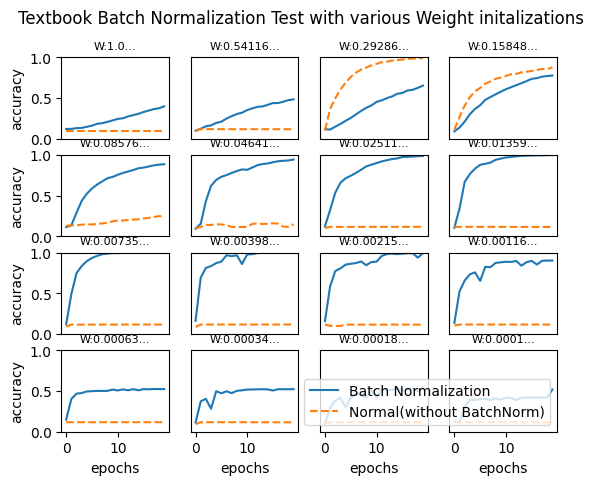

In [9]:
# 그래프 그리기==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print("============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4, 4, i+1)
    plt.title("W:" + str(w)[:7] +'...', fontdict = {'fontsize' : 8})
    if i == 15:
        plt.plot(x, bn_train_acc_list,
                 label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle="--",
                 label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
plt.legend(loc='lower right')

plt.suptitle('Textbook Batch Normalization Test with various Weight initalizations')
plt.subplots_adjust(bottom=0.1)
plt.show()


## My code

In [1]:
# coding: utf-8
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from my_models import SGD, MultiLayerNet

In [2]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01

In [3]:
def __train(weight_init_std):
    bn_network = MultiLayerNet(input_size=784,
                                     hidden_size_list=[100, 100, 100, 100, 100],
                                     output_size=10,
                                     weight_init_std=weight_init_std,
                                     batch_norm=True)
    network = MultiLayerNet(input_size=784,
                                  hidden_size_list=[100, 100, 100, 100, 100],
                                  output_size=10,
                                  weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - "
                  + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list




============== 1/16 ==============
epoch:0 | 0.093 - 0.054
epoch:1 | 0.097 - 0.051


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:50: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:44: RuntimeWarning: overflow encountered in matmul
  out = x @ self.W + self.b
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:27: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


epoch:2 | 0.097 - 0.055
epoch:3 | 0.097 - 0.058
epoch:4 | 0.097 - 0.063
epoch:5 | 0.097 - 0.062
epoch:6 | 0.097 - 0.064
epoch:7 | 0.097 - 0.07
epoch:8 | 0.097 - 0.071
epoch:9 | 0.097 - 0.073
epoch:10 | 0.097 - 0.073
epoch:11 | 0.097 - 0.076
epoch:12 | 0.097 - 0.077
epoch:13 | 0.097 - 0.076
epoch:14 | 0.097 - 0.077
epoch:15 | 0.097 - 0.08
epoch:16 | 0.097 - 0.082
epoch:17 | 0.097 - 0.087
epoch:18 | 0.097 - 0.084
epoch:19 | 0.097 - 0.086
============== 2/16 ==============
epoch:0 | 0.117 - 0.099


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:44: RuntimeWarning: invalid value encountered in matmul
  out = x @ self.W + self.b
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:49: RuntimeWarning: invalid value encountered in matmul
  self.dW = self.x.T @ dout


epoch:1 | 0.097 - 0.1
epoch:2 | 0.097 - 0.105
epoch:3 | 0.097 - 0.105
epoch:4 | 0.097 - 0.104
epoch:5 | 0.097 - 0.106
epoch:6 | 0.097 - 0.107
epoch:7 | 0.097 - 0.108
epoch:8 | 0.097 - 0.108
epoch:9 | 0.097 - 0.108
epoch:10 | 0.097 - 0.109
epoch:11 | 0.097 - 0.109
epoch:12 | 0.097 - 0.108
epoch:13 | 0.097 - 0.108
epoch:14 | 0.097 - 0.108
epoch:15 | 0.097 - 0.11
epoch:16 | 0.097 - 0.111
epoch:17 | 0.097 - 0.111
epoch:18 | 0.097 - 0.112
epoch:19 | 0.097 - 0.111
============== 3/16 ==============
epoch:0 | 0.121 - 0.101
epoch:1 | 0.439 - 0.117
epoch:2 | 0.592 - 0.123
epoch:3 | 0.65 - 0.127
epoch:4 | 0.749 - 0.133
epoch:5 | 0.781 - 0.135
epoch:6 | 0.841 - 0.145
epoch:7 | 0.876 - 0.149
epoch:8 | 0.903 - 0.154
epoch:9 | 0.926 - 0.155
epoch:10 | 0.944 - 0.158
epoch:11 | 0.963 - 0.16
epoch:12 | 0.966 - 0.163
epoch:13 | 0.97 - 0.162
epoch:14 | 0.978 - 0.164
epoch:15 | 0.98 - 0.168
epoch:16 | 0.984 - 0.168


KeyboardInterrupt: 

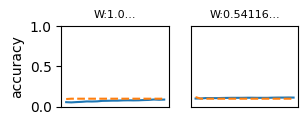

In [4]:
# 그래프 그리기==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print("============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4, 4, i+1)
    plt.title("W:" + str(w)[:7] +'...', fontdict = {'fontsize' : 8})
    if i == 15:
        plt.plot(x, bn_train_acc_list,
                 label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle="--",
                 label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
plt.legend(loc='lower right')

plt.suptitle('MY OWN batch normalization test')
plt.subplots_adjust(bottom=0.1)
plt.show()


## What if batch norm layer is after activ.?

## My code

In [1]:
# coding: utf-8
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from my_models import SGD, MultiLayerNet

In [2]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01

In [3]:
def __train(weight_init_std):
    bn_network = MultiLayerNet(input_size=784,
                                     hidden_size_list=[100, 100, 100, 100, 100],
                                     output_size=10,
                                     weight_init_std=weight_init_std,
                                     batch_norm=True)
    network = MultiLayerNet(input_size=784,
                                  hidden_size_list=[100, 100, 100, 100, 100],
                                  output_size=10,
                                  weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - "
                  + str(bn_train_acc))

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list




============== 1/16 ==============
epoch:0 | 0.097 - 0.127
epoch:1 | 0.097 - 0.129


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:50: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:43: RuntimeWarning: overflow encountered in matmul
  out = x @ self.W + self.b
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:27: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


epoch:2 | 0.097 - 0.13
epoch:3 | 0.097 - 0.136
epoch:4 | 0.097 - 0.139
epoch:5 | 0.097 - 0.138
epoch:6 | 0.097 - 0.141
epoch:7 | 0.097 - 0.141
epoch:8 | 0.097 - 0.146
epoch:9 | 0.097 - 0.149
epoch:10 | 0.097 - 0.15
epoch:11 | 0.097 - 0.152
epoch:12 | 0.097 - 0.156
epoch:13 | 0.097 - 0.155
epoch:14 | 0.097 - 0.153
epoch:15 | 0.097 - 0.156
epoch:16 | 0.097 - 0.156
epoch:17 | 0.097 - 0.16
epoch:18 | 0.097 - 0.163
epoch:19 | 0.097 - 0.161
============== 2/16 ==============
epoch:0 | 0.117 - 0.094


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:43: RuntimeWarning: invalid value encountered in matmul
  out = x @ self.W + self.b
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:48: RuntimeWarning: invalid value encountered in matmul
  self.dW = self.x.T @ dout


epoch:1 | 0.097 - 0.1
epoch:2 | 0.097 - 0.105
epoch:3 | 0.097 - 0.107
epoch:4 | 0.097 - 0.109
epoch:5 | 0.097 - 0.113
epoch:6 | 0.097 - 0.114
epoch:7 | 0.097 - 0.117
epoch:8 | 0.097 - 0.12
epoch:9 | 0.097 - 0.125
epoch:10 | 0.097 - 0.124
epoch:11 | 0.097 - 0.126
epoch:12 | 0.097 - 0.127
epoch:13 | 0.097 - 0.13
epoch:14 | 0.097 - 0.13
epoch:15 | 0.097 - 0.134
epoch:16 | 0.097 - 0.136
epoch:17 | 0.097 - 0.136
epoch:18 | 0.097 - 0.139
epoch:19 | 0.097 - 0.142
============== 3/16 ==============
epoch:0 | 0.112 - 0.085
epoch:1 | 0.232 - 0.085
epoch:2 | 0.38 - 0.097
epoch:3 | 0.456 - 0.1
epoch:4 | 0.527 - 0.11
epoch:5 | 0.604 - 0.117
epoch:6 | 0.643 - 0.137
epoch:7 | 0.697 - 0.141
epoch:8 | 0.745 - 0.144
epoch:9 | 0.77 - 0.149
epoch:10 | 0.802 - 0.161
epoch:11 | 0.804 - 0.162
epoch:12 | 0.832 - 0.168
epoch:13 | 0.846 - 0.173
epoch:14 | 0.861 - 0.176
epoch:15 | 0.875 - 0.181
epoch:16 | 0.89 - 0.184
epoch:17 | 0.893 - 0.184
epoch:18 | 0.895 - 0.184
epoch:19 | 0.917 - 0.186
============== 4/16 

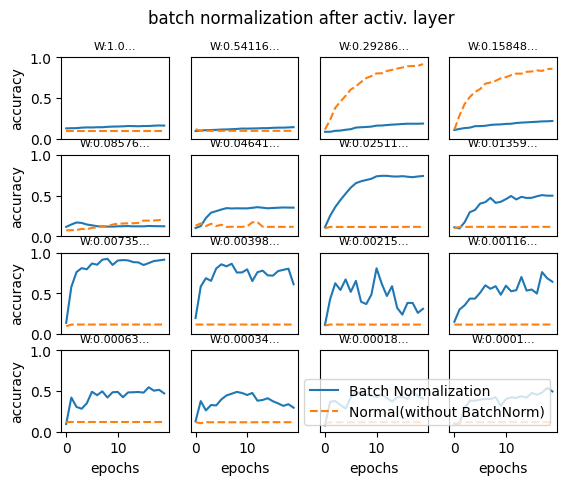

In [5]:
# 그래프 그리기==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print("============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4, 4, i+1)
    plt.title("W:" + str(w)[:7] +'...', fontdict = {'fontsize' : 8})
    if i == 15:
        plt.plot(x, bn_train_acc_list,
                 label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle="--",
                 label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
plt.legend(loc='lower right')

plt.suptitle('batch normalization after activ. layer')
plt.subplots_adjust(bottom=0.1)
plt.show()


## Batch norm accuracy test

In [1]:
import sys, os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('./official_github/')
from dataset.mnist import load_mnist
from my_models import MultiLayerNet, TwoLayerNet, batch_mask_loader, SGD, Momentum, AdaGrad, Adam, RMSProp
# from common.optimizer import *
from common.util import smooth_curve


np.random.seed(42)

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)


epoch = 10
eval_per_step = 600
train_size = x_train.shape[0]
batch_size = 200
learning_rate = 0.01


In [2]:
outputs_dict = defaultdict(list)
batch_norm_options = ('before', 'after', 'False')

for batch_norm_option in batch_norm_options:
    network = MultiLayerNet(input_size=784,
                            hidden_size_list=[100, 100, 100, 100, 100],
                            output_size=10,
                            batch_norm=batch_norm_option)
    optimizer = SGD()
    print(batch_norm_option)
    
    for epoch_idx in range(1, epoch+1):
        print(f"===== {epoch_idx} epoch started =====")
        batch_mask_generator = batch_mask_loader(x_train, batch_size=100)
        
        train_loss_list = []
        train_acc_list = []
        test_acc_list = []
        
        for batch_mask in batch_mask_generator:

            x_batch = x_train[batch_mask]
            t_batch = t_train[batch_mask]

            # print(x_batch.shape, t_batch.shape)
            # print('predict x batch shape', network.predict(x_batch).shape)

            # grads = network.numerical_gradient(x_batch, t_batch)
            grads = network.gradient(x_batch, t_batch)

            optimizer.update(network.params, grads)

            loss = network.loss(x_batch, t_batch)
            # print(f'{iter_idx} loss: {loss}')
            train_loss_list.append(loss)

        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f'===== train acc: {train_acc}, test acc: {test_acc} =====')

    
    outputs_dict[f'{batch_norm_option} loss'] = train_loss_list
    outputs_dict[f'{batch_norm_option} train acc'] = train_acc_list
    outputs_dict[f'{batch_norm_option} test acc'] = test_acc_list

    print(f'final train acc:{network.accuracy(x_train, t_train)}')
    print(f'final test acc:{network.accuracy(x_test, t_test)}') 

False
===== 1 epoch started =====


KeyboardInterrupt: 

In [ ]:
outputs_dict

defaultdict(list,
            {'False loss': [0.06907066817696583,
              0.0857589346373072,
              0.0504103960588801,
              0.1714666155561639,
              0.13975189737775529,
              0.035696617472539216,
              0.07036580978758562,
              0.06216746052924549,
              0.050334047186260875,
              0.04436785170088544,
              0.08519513316189004,
              0.05467261259681076,
              0.12349530407678909,
              0.027855691677154973,
              0.0942883335458077,
              0.055772570137833946,
              0.07836943903095442,
              0.06268603373294714,
              0.11140646474569643,
              0.06196287524575232,
              0.032243208645722186,
              0.13825971180934707,
              0.04504547949379302,
              0.08180223661581387,
              0.10716081301486811,
              0.07146536668687013,
              0.1186955448915334,
              0.1101140

In [ ]:
for key, value in outputs_dict.items():
    print(key)

False loss
False train acc
False test acc
